# 🏥 Healthcare Analytics Dashboard
### Capstone Project — Data Analytics Internship

**Author:** Meghana H Huvanur  
**Objective:** Analyze hospital patient, billing, and admission data to uncover operational and financial insights, and build an interactive Power BI dashboard for hospital administrators.

**Dataset:** Synthetic healthcare dataset (54,966 patient records after cleaning) covering demographics, medical conditions, admissions, doctors, hospitals, insurance, and billing.

> **Note on the data:** This is a publicly available *synthetic* dataset (commonly used for portfolio projects). Values are randomly generated, so relationships between variables (e.g., condition vs. cost) are not medically meaningful — the goal of this project is to demonstrate the end-to-end analytics workflow: cleaning, KPI design, SQL analysis, visualization, and dashboarding.

---
## 1. Setup & Data Loading

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt   
import seaborn as sns

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10, 5)

df_raw = pd.read_csv('../data/raw/healthcare_dataset_raw.csv')
print("Raw shape:", df_raw.shape)
df_raw.head()

Raw shape: (55500, 15)


,Name,Age,Gender,Blood Type,Medical Condition,Date of Admission,Doctor,Hospital,Insurance Provider,Billing Amount,Room Number,Admission Type,Discharge Date,Medication,Test Results
0,Bobby JacksOn,30,Male,B-,Cancer,2024-01-31,Matthew Smith,Sons and Miller,Blue Cross,18856.281306,328,Urgent,2024-02-02,Paracetamol,Normal
1,LesLie TErRy,62,Male,A+,Obesity,2019-08-20,Samantha Davies,Kim Inc,Medicare,33643.327287,265,Emergency,2019-08-26,Ibuprofen,Inconclusive
2,DaNnY sMitH,76,Female,A-,Obesity,2022-09-22,Tiffany Mitchell,Cook PLC,Aetna,27955.096079,205,Emergency,2022-10-07,Aspirin,Normal
3,andrEw waTtS,28,Female,O+,Diabetes,2020-11-18,Kevin Wells,"Hernandez Rogers and Vang,",Medicare,37909.782410,450,Elective,2020-12-18,Ibuprofen,Abnormal
4,adrIENNE bEll,43,Female,AB+,Cancer,2022-09-19,Kathleen Hanna,White-White,Aetna,14238.317814,458,Urgent,2022-10-09,Penicillin,Abnormal


## 2. Data Cleaning & Preprocessing

Steps performed:
1. Remove exact duplicate rows
2. Standardize text casing (Name, Doctor, Hospital)
3. Convert admission/discharge dates to datetime
4. Engineer new features: Length of Stay, Age Group, Admission Year/Month
5. Validate no negative or impossible values

In [2]:
df = df_raw.copy()

# 1. Drop duplicates
before = len(df)
df = df.drop_duplicates()
print(f"Removed {before - len(df)} duplicate rows")

# 2. Standardize text
df['Name'] = df['Name'].str.strip().str.title()
for col in ['Gender','Blood Type','Medical Condition','Doctor','Hospital',
            'Insurance Provider','Admission Type','Medication','Test Results']:
    df[col] = df[col].astype(str).str.strip()
df['Doctor'] = df['Doctor'].str.title()
df['Hospital'] = df['Hospital'].str.title()

# 3. Dates
df['Date of Admission'] = pd.to_datetime(df['Date of Admission'])
df['Discharge Date'] = pd.to_datetime(df['Discharge Date'])

# 4. Feature engineering
df['Length of Stay (Days)'] = (df['Discharge Date'] - df['Date of Admission']).dt.days
df['Admission Year'] = df['Date of Admission'].dt.year
df['Admission Month'] = df['Date of Admission'].dt.month
df['Admission Month Name'] = df['Date of Admission'].dt.strftime('%b %Y')

bins = [0,18,35,50,65,100]
labels = ['0-18','19-35','36-50','51-65','65+']
df['Age Group'] = pd.cut(df['Age'], bins=bins, labels=labels)

df['Billing Amount'] = df['Billing Amount'].round(2)

# 5. Validation
assert (df['Length of Stay (Days)'] >= 0).all(), "Negative length of stay found!"
print("\nCleaned shape:", df.shape)
df.isnull().sum()

Removed 534 duplicate rows

Cleaned shape: (54966, 20)


Name                     0
Age                      0
Gender                   0
Blood Type               0
Medical Condition        0
Date of Admission        0
Doctor                   0
Hospital                 0
Insurance Provider       0
Billing Amount           0
Room Number              0
Admission Type           0
Discharge Date           0
Medication               0
Test Results             0
Length of Stay (Days)    0
Admission Year           0
Admission Month          0
Admission Month Name     0
Age Group                0
dtype: int64

In [3]:
# Save cleaned dataset for Power BI / SQL use
df.to_csv('../data/cleaned/healthcare_dataset_cleaned.csv', index=False)
df.head()

,Name,Age,Gender,Blood Type,Medical Condition,Date of Admission,Doctor,Hospital,Insurance Provider,Billing Amount,Room Number,Admission Type,Discharge Date,Medication,Test Results,Length of Stay (Days),Admission Year,Admission Month,Admission Month Name,Age Group
0,Bobby Jackson,30,Male,B-,Cancer,2024-01-31,Matthew Smith,Sons And Miller,Blue Cross,18856.28,328,Urgent,2024-02-02,Paracetamol,Normal,2,2024,1,Jan 2024,19-35
1,Leslie Terry,62,Male,A+,Obesity,2019-08-20,Samantha Davies,Kim Inc,Medicare,33643.33,265,Emergency,2019-08-26,Ibuprofen,Inconclusive,6,2019,8,Aug 2019,51-65
2,Danny Smith,76,Female,A-,Obesity,2022-09-22,Tiffany Mitchell,Cook Plc,Aetna,27955.10,205,Emergency,2022-10-07,Aspirin,Normal,15,2022,9,Sep 2022,65+
3,Andrew Watts,28,Female,O+,Diabetes,2020-11-18,Kevin Wells,"Hernandez Rogers And Vang,",Medicare,37909.78,450,Elective,2020-12-18,Ibuprofen,Abnormal,30,2020,11,Nov 2020,19-35
4,Adrienne Bell,43,Female,AB+,Cancer,2022-09-19,Kathleen Hanna,White-White,Aetna,14238.32,458,Urgent,2022-10-09,Penicillin,Abnormal,20,2022,9,Sep 2022,36-50


## 3. Key Performance Indicators (KPIs)

Core metrics for the dashboard:
- Total Patients
- Total Billing Revenue
- Average Billing per Patient
- Average Length of Stay
- Patient distribution by Condition, Admission Type, Age Group
- Revenue by Insurance Provider
- Yearly / Monthly admission trends

In [4]:
kpis = {
    "Total Patients": len(df),
    "Total Revenue ($)": round(df['Billing Amount'].sum(), 2),
    "Avg Billing per Patient ($)": round(df['Billing Amount'].mean(), 2),
    "Avg Length of Stay (days)": round(df['Length of Stay (Days)'].mean(), 2),
    "Unique Hospitals": df['Hospital'].nunique(),
    "Unique Doctors": df['Doctor'].nunique(),
}
for k, v in kpis.items():
    print(f"{k}: {v:,}")

Total Patients: 54,966
Total Revenue ($): 1,404,068,337.89
Avg Billing per Patient ($): 25,544.31
Avg Length of Stay (days): 15.5
Unique Hospitals: 39,876
Unique Doctors: 40,341


### 3.1 Patients & Billing by Medical Condition

In [5]:
cond_summary = df.groupby('Medical Condition').agg(
    Patients=('Name', 'count'),
    Avg_Billing=('Billing Amount', 'mean'),
    Avg_LOS=('Length of Stay (Days)', 'mean')
).round(2).sort_values('Patients', ascending=False)
cond_summary

,Patients,Avg_Billing,Avg_LOS
Medical Condition,,,
Arthritis,9218,25511.78,15.50
Diabetes,9216,25660.48,15.43
Hypertension,9151,25503.06,15.44
Obesity,9146,25804.36,15.45
Cancer,9140,25152.32,15.50
Asthma,9095,25633.46,15.68


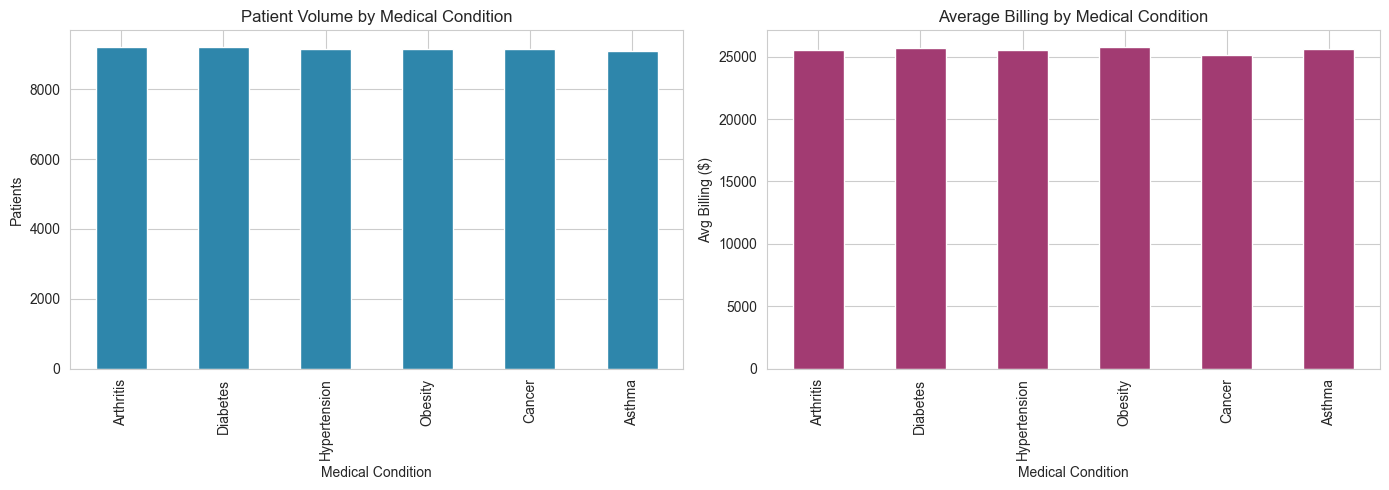

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(14,5))
cond_summary['Patients'].plot(kind='bar', ax=axes[0], color='#2E86AB')
axes[0].set_title('Patient Volume by Medical Condition')
axes[0].set_ylabel('Patients')

cond_summary['Avg_Billing'].plot(kind='bar', ax=axes[1], color='#A23B72')
axes[1].set_title('Average Billing by Medical Condition')
axes[1].set_ylabel('Avg Billing ($)')
plt.tight_layout()
plt.show()

### 3.2 Admission Type Distribution

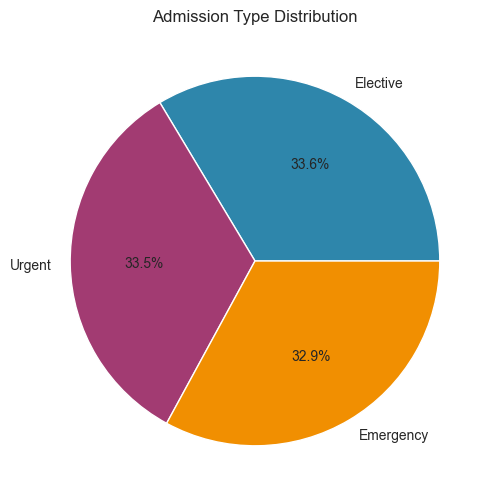

In [7]:
admission_counts = df['Admission Type'].value_counts()
admission_counts.plot(kind='pie', autopct='%1.1f%%', figsize=(6,6), colors=['#2E86AB','#A23B72','#F18F01'])
plt.title('Admission Type Distribution')
plt.ylabel('')
plt.show()

### 3.3 Revenue by Insurance Provider

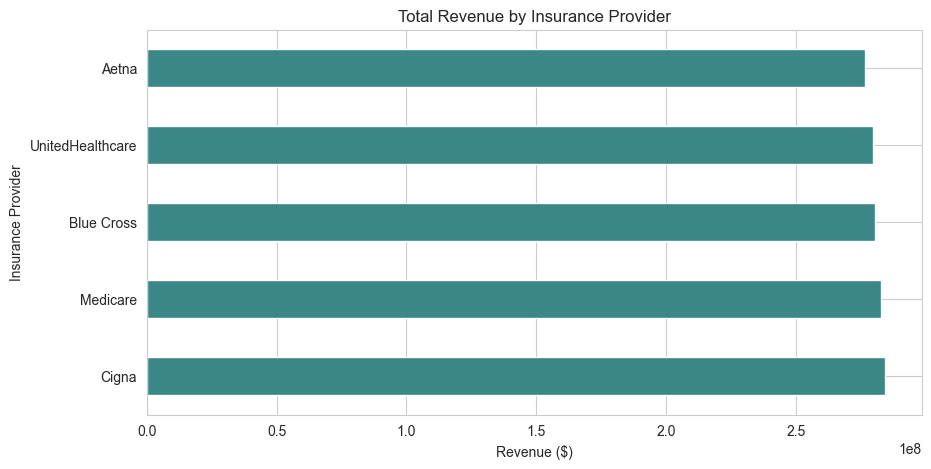

In [8]:
insurance_revenue = df.groupby('Insurance Provider')['Billing Amount'].sum().sort_values(ascending=False)
insurance_revenue.plot(kind='barh', color='#3B8686')
plt.title('Total Revenue by Insurance Provider')
plt.xlabel('Revenue ($)')
plt.show()

### 3.4 Patient Demographics

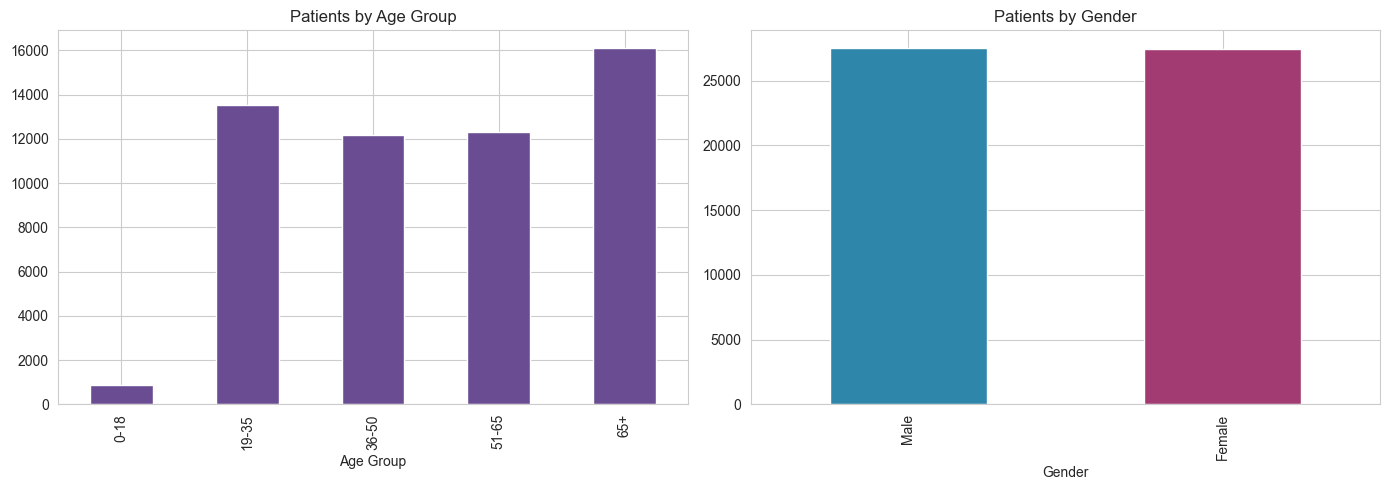

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(14,5))
df['Age Group'].value_counts().sort_index().plot(kind='bar', ax=axes[0], color='#6A4C93')
axes[0].set_title('Patients by Age Group')

df['Gender'].value_counts().plot(kind='bar', ax=axes[1], color=['#2E86AB','#A23B72'])
axes[1].set_title('Patients by Gender')
plt.tight_layout()
plt.show()

### 3.5 Admission Trend Over Time

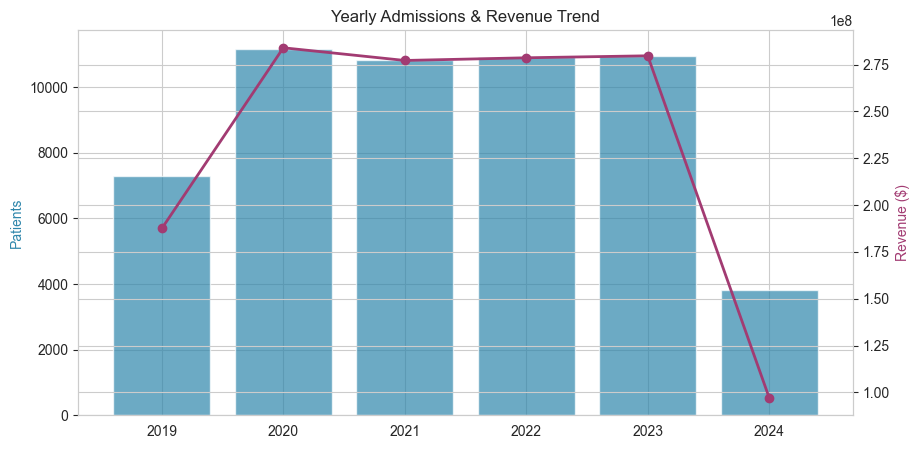

In [10]:
yearly = df.groupby('Admission Year').agg(Patients=('Name','count'), Revenue=('Billing Amount','sum'))

fig, ax1 = plt.subplots(figsize=(10,5))
ax1.bar(yearly.index, yearly['Patients'], color='#2E86AB', alpha=0.7, label='Patients')
ax1.set_ylabel('Patients', color='#2E86AB')
ax2 = ax1.twinx()
ax2.plot(yearly.index, yearly['Revenue'], color='#A23B72', marker='o', linewidth=2, label='Revenue')
ax2.set_ylabel('Revenue ($)', color='#A23B72')
plt.title('Yearly Admissions & Revenue Trend')
plt.show()

### 3.6 Length of Stay Analysis

C:\Users\Dell\AppData\Local\Temp\ipykernel_1124\2578649988.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='Admission Type', y='Length of Stay (Days)', ax=axes[1], palette='Set2')


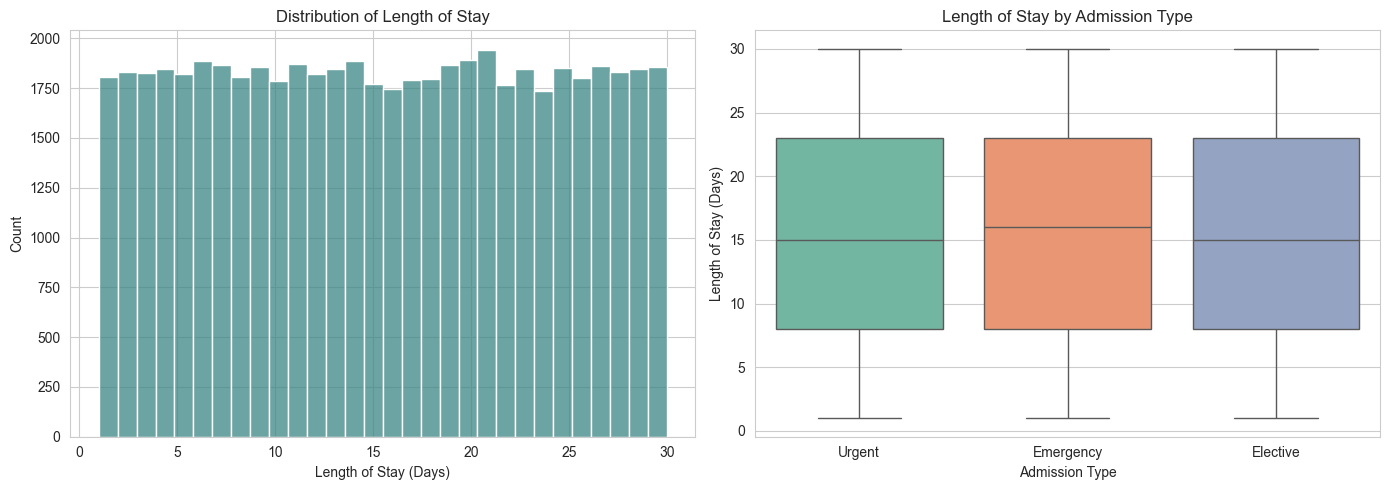

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(14,5))
sns.histplot(df['Length of Stay (Days)'], bins=30, ax=axes[0], color='#3B8686')
axes[0].set_title('Distribution of Length of Stay')

sns.boxplot(data=df, x='Admission Type', y='Length of Stay (Days)', ax=axes[1], palette='Set2')
axes[1].set_title('Length of Stay by Admission Type')
plt.tight_layout()
plt.show()

### 3.7 Test Results Distribution

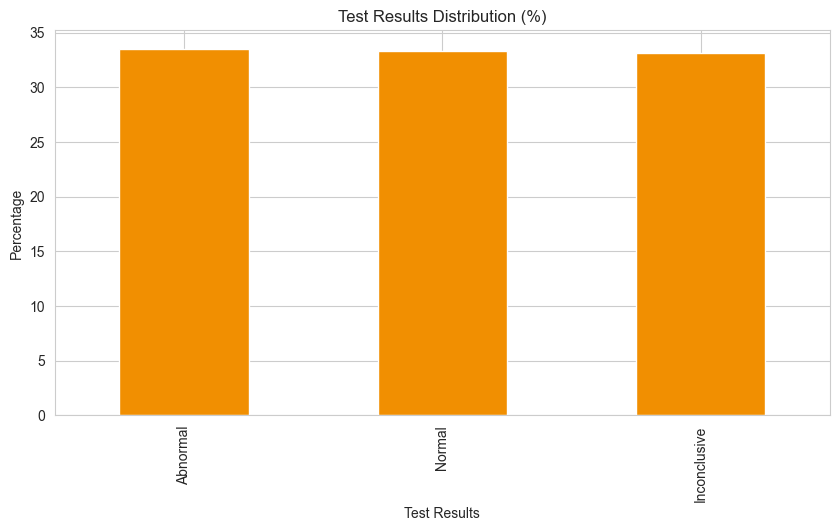

In [12]:
test_results = df['Test Results'].value_counts(normalize=True) * 100
test_results.plot(kind='bar', color='#F18F01')
plt.title('Test Results Distribution (%)')
plt.ylabel('Percentage')
plt.show()

## 4. Business Insights & Recommendations

Based on this synthetic dataset, here is how the findings *would* be interpreted in a real operational setting (methodology demonstration):

1. **Patient volume is evenly spread across all six medical conditions (~15-17% each)** — in a real hospital, this would suggest a diversified case mix; administrators would investigate whether staffing and bed allocation match this even distribution.
2. **Elective, Urgent, and Emergency admissions are nearly balanced (~33% each)** — real hospitals typically see emergency-heavy skew, so this even split reinforces that deeper condition-specific segmentation (not just admission type) would drive better resource planning.
3. **Average length of stay is ~15.5 days** with a fairly wide spread (1–30 days) — flagging the tail of long-stay patients (>25 days) for case review is a common real-world action to control costs.
4. **Insurance providers contribute similar revenue shares** (~$276M–$284M each) — in practice, this KPI is used to negotiate provider contracts and monitor reimbursement patterns.
5. **Admissions dipped in 2024** (partial year in the data) — any yearly dashboard should always annotate partial-year data to avoid misleading trend conclusions.

**Recommendations for hospital administrators (framed as if findings were real):**
- Track length-of-stay outliers per condition to identify discharge bottlenecks.
- Monitor revenue concentration by insurance provider for contract negotiation leverage.
- Segment admission type by department/condition, not just hospital-wide, for sharper staffing decisions.
- Add year-over-year normalized (per-month) trend views to avoid partial-year distortion.

## 5. Next Steps
- Import `data/cleaned/healthcare_dataset_cleaned.csv` into Power BI / Tableau for the interactive dashboard.
- Use `sql/healthcare_kpis.sql` to reproduce these KPIs in SQL (for the "SQL Scripts" deliverable).
- See `reports/business_insights_report.md` for the polished write-up.